In [29]:
import pandas as pd

data= pd.read_csv(r"C:\Users\nidhi\OneDrive\Desktop\Heart disease\heart.csv")

In [30]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [31]:
print(data.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [32]:
data.info

<bound method DataFrame.info of       age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2

In [33]:
data.shape

(1025, 14)

In [6]:
data.isnull().sum().sort_values(ascending=False)
(data.isnull().mean()*100).sort_values(ascending=False)

#hence, no data is missing


age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64

In [34]:
#Renaming the columns

data.rename(columns={
    'cp': 'chest pain type',
    'trestbps': 'resting blood pressure',
    'chol': 'serum cholestrol in mg/dl',
    'fbs': 'fasting blood sugar>120 mg/dl',
    'restecg': 'resting electrocardiographic results',
    'thalach': 'max heart rate achieved',
    'exang': 'exercise induced angina',
    'oldpeak': 'ST depression',
    'slope': 'the slope of the peak exercise ST segment',
    'ca': 'number of major vessels',
    'thal': ' thalasemia'
}, inplace=True)

In [35]:
data.sample(10)

,age,sex,chest pain type,resting blood pressure,serum cholestrol in mg/dl,fasting blood sugar>120 mg/dl,resting electrocardiographic results,max heart rate achieved,exercise induced angina,ST depression,the slope of the peak exercise ST segment,number of major vessels,thalasemia,target
573,44,1,0,112,290,0,0,153,0,0.0,2,1,2,0
382,59,1,0,110,239,0,0,142,1,1.2,1,1,3,0
158,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
864,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0
836,53,0,0,138,234,0,0,160,0,0.0,2,0,2,1
643,65,1,0,120,177,0,1,140,0,0.4,2,0,3,1
664,66,0,3,150,226,0,1,114,0,2.6,0,0,2,1
122,60,1,0,145,282,0,0,142,1,2.8,1,2,3,0
889,63,0,0,150,407,0,0,154,0,4.0,1,3,3,0


In [36]:
print(data['age'].unique())

[52 53 70 61 62 58 55 46 54 71 43 34 51 50 60 67 45 63 42 44 56 57 59 64
 65 41 66 38 49 48 29 37 47 68 76 40 39 77 69 35 74]


In [37]:
#finding the correlation between the columns

numeric_data = data.drop(columns=['age'])

correlation = numeric_data.corr()['target'].sort_values(ascending=False)

print(correlation)

target                                       1.000000
chest pain type                              0.434854
max heart rate achieved                      0.422895
the slope of the peak exercise ST segment    0.345512
resting electrocardiographic results         0.134468
fasting blood sugar>120 mg/dl               -0.041164
serum cholestrol in mg/dl                   -0.099966
resting blood pressure                      -0.138772
sex                                         -0.279501
 thalasemia                                 -0.337838
number of major vessels                     -0.382085
exercise induced angina                     -0.438029
ST depression                               -0.438441
Name: target, dtype: float64


In [38]:
#plotting the correlation graph
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation of all features with target
correlation = data.corr()['target'].sort_values(ascending=False)
print(correlation)




target                                       1.000000
chest pain type                              0.434854
max heart rate achieved                      0.422895
the slope of the peak exercise ST segment    0.345512
resting electrocardiographic results         0.134468
fasting blood sugar>120 mg/dl               -0.041164
serum cholestrol in mg/dl                   -0.099966
resting blood pressure                      -0.138772
age                                         -0.229324
sex                                         -0.279501
 thalasemia                                 -0.337838
number of major vessels                     -0.382085
exercise induced angina                     -0.438029
ST depression                               -0.438441
Name: target, dtype: float64


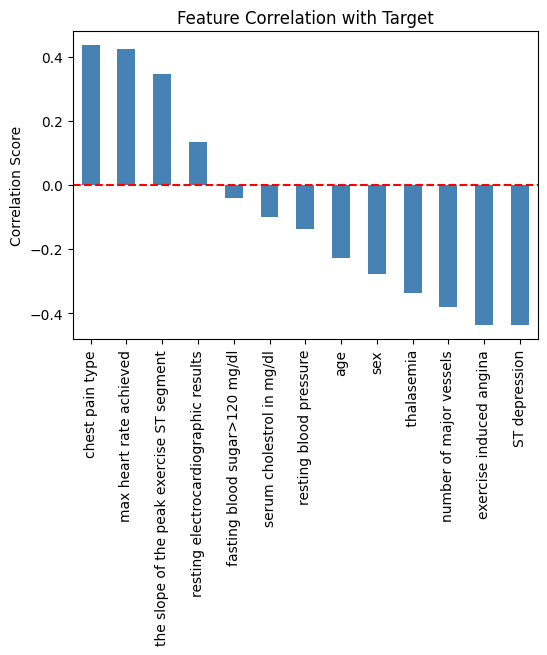

In [39]:

plt.figure(figsize=(6,4))
correlation.drop('target').plot(kind='bar', color='steelblue')
plt.title('Feature Correlation with Target')
plt.axhline(y=0, color='red', linestyle='--')
plt.ylabel('Correlation Score')
plt.show()

In [40]:
age_map = {
    '20-30': 25,
    '30-40': 35,
    '40-50': 45,
    '50-60': 55,
    '60-70': 65,
    '70-80': 75
}

data['age_group_numeric'] = data['age'].map(age_map)

In [41]:
data.select_dtypes(include=['number']).shape

(1025, 15)

In [42]:
print(data['target'].value_counts())
print(data['exercise induced angina'].value_counts())

# Most important — see the actual relationship
print(data.groupby('exercise induced angina')['target'].mean())

target
1    526
0    499
Name: count, dtype: int64
exercise induced angina
0    680
1    345
Name: count, dtype: int64
exercise induced angina
0    0.669118
1    0.205797
Name: target, dtype: float64


In [43]:
# Check exang vs target
print("exercise induced angina vs target:")
print(data.groupby('exercise induced angina')['target'].mean())
print()

# Check ca vs target  
print("number of major vessels vs target:")
print(data.groupby('number of major vessels')['target'].mean())
print()

# Check ST depression vs target
print("ST depression vs target:")
print(data.groupby('target')['ST depression'].mean())

exercise induced angina vs target:
exercise induced angina
0    0.669118
1    0.205797
Name: target, dtype: float64

number of major vessels vs target:
number of major vessels
0    0.717993
1    0.292035
2    0.156716
3    0.130435
4    0.833333
Name: target, dtype: float64

ST depression vs target:
target
0    1.600200
1    0.569962
Name: ST depression, dtype: float64


In [26]:
# Flip the target
data['target'] = 1 - data['target']

# Verify after flipping
print(data['target'].value_counts())
print()
print(data.groupby('exercise induced angina')['target'].mean())
print()
print(data.groupby('target')['ST depression'].mean())

target
0    526
1    499
Name: count, dtype: int64

exercise induced angina
0    0.330882
1    0.794203
Name: target, dtype: float64

target
0    0.569962
1    1.600200
Name: ST depression, dtype: float64


target                                       1.000000
chest pain type                              0.434854
max heart rate achieved                      0.422895
the slope of the peak exercise ST segment    0.345512
resting electrocardiographic results         0.134468
fasting blood sugar>120 mg/dl               -0.041164
serum cholestrol in mg/dl                   -0.099966
resting blood pressure                      -0.138772
age                                         -0.229324
sex                                         -0.279501
 thalasemia                                 -0.337838
number of major vessels                     -0.382085
exercise induced angina                     -0.438029
ST depression                               -0.438441
age_group_numeric                                 NaN
Name: target, dtype: float64


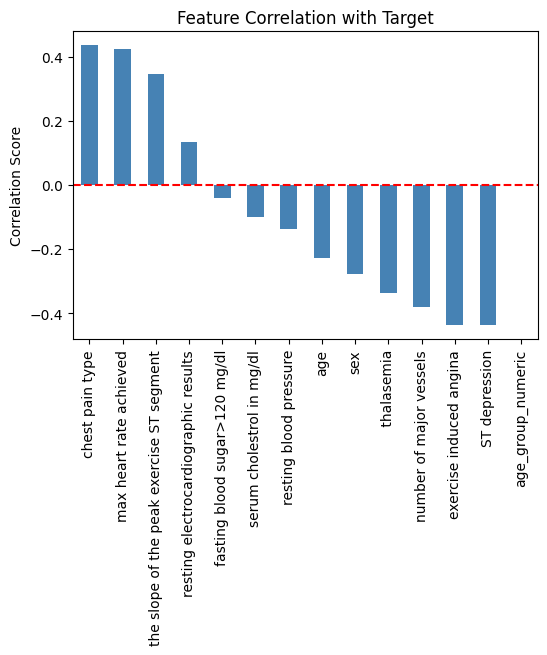

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation of all features with target
correlation = data.corr()['target'].sort_values(ascending=False)
print(correlation)

plt.figure(figsize=(6,4))
correlation.drop('target').plot(kind='bar', color='steelblue')
plt.title('Feature Correlation with Target')
plt.axhline(y=0, color='red', linestyle='--')
plt.ylabel('Correlation Score')
plt.show()

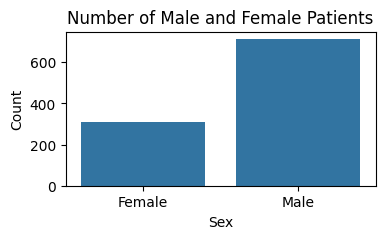

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,2))

sns.countplot(data=data, x='sex')

plt.xticks([0, 1], ['Female', 'Male'])
plt.title('Number of Male and Female Patients')
plt.xlabel('Sex')
plt.ylabel('Count')

plt.show()

#OBSERVATION - No. of male patients > No. of female patients

In [11]:
#creating age groups
import pandas as pd

data['age_group'] = pd.cut(
    data['age'],
    bins=[20, 30, 40, 50, 60, 70, 80],
    labels=['20-30', '30-40', '40-50', '50-60', '60-70', '70-80']
)

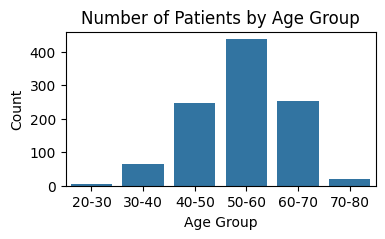

In [12]:
#Plotting age group graph
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,2))

sns.countplot(
    data=data,
    x='age_group'
)

plt.title('Number of Patients by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')

plt.show()

#OBSERVATION - In the data set- 50-60> 40-50= 60-70> 30-40> 70-80> 20-30

<Axes: ylabel='resting blood pressure'>

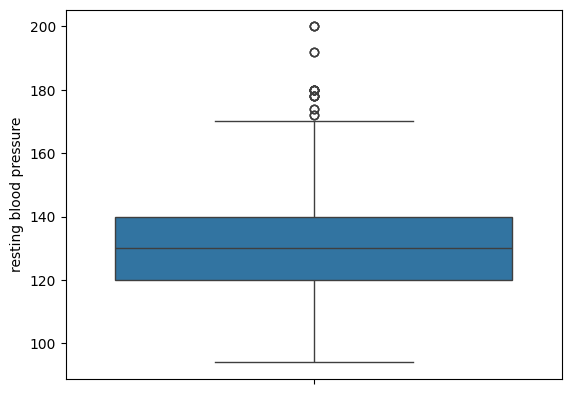

In [13]:
#finding otliners
import seaborn as sns 

#1. outliner in resting blood pressure
sns.boxplot(y=data['resting blood pressure'])

<Axes: ylabel='serum cholestrol in mg/dl'>

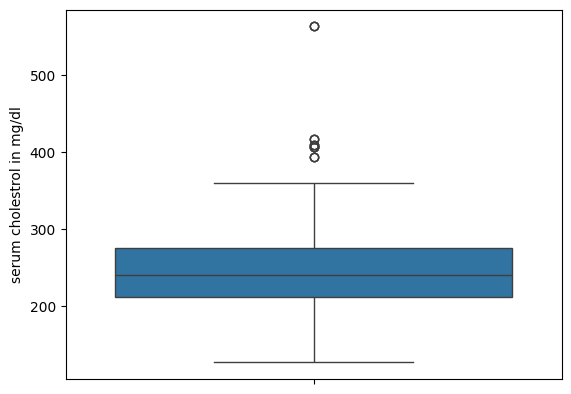

In [14]:
#2. Outliner in serum cholestrol mg/dl

sns.boxplot(y=data['serum cholestrol in mg/dl'])

<Axes: ylabel='max heart rate achieved'>

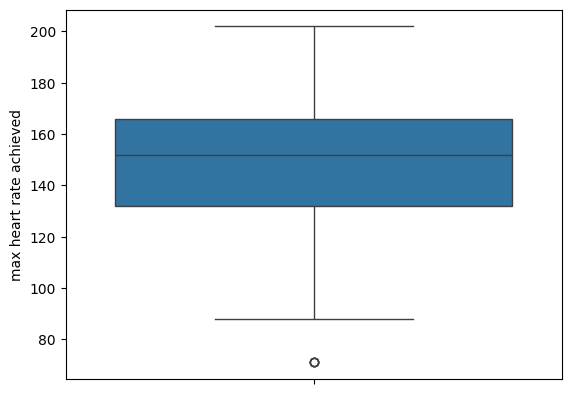

In [15]:
#3. Outliner in max heart rate achieved

sns.boxplot(y=data['max heart rate achieved'])

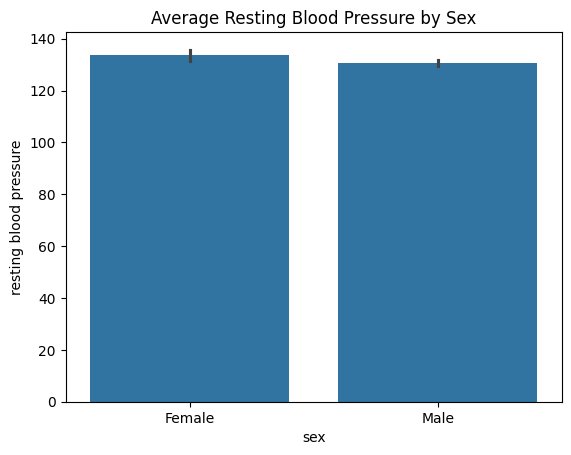

In [16]:
#Graph plots on the basis of sex
import matplotlib.pyplot as plt

sns.barplot(
    data=data,
    x='sex',
    y='resting blood pressure'
)

plt.xticks([0, 1], ['Female', 'Male'])
plt.title('Average Resting Blood Pressure by Sex')
plt.show()

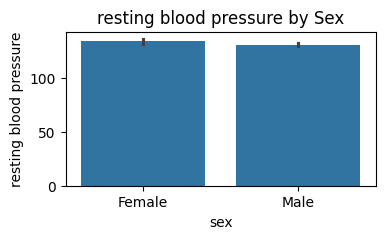

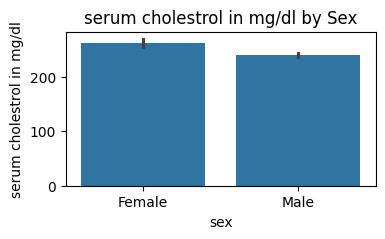

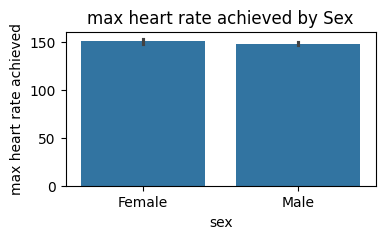

In [17]:
features = [
    'resting blood pressure',
    'serum cholestrol in mg/dl',
    'max heart rate achieved'
]

for feature in features:
    plt.figure(figsize=(4,2))

    sns.barplot(
        data=data,
        x='sex',
        y=feature
    )

    plt.xticks([0,1], ['Female', 'Male'])
    plt.title(f'{feature} by Sex')
    plt.show()

    


2.KEY INSIGHTS FROM THE SERUM CHOLESTROL in mg/dl by sex Graph
Normal cholesterol is below 200 mg/dl
Both males and females in this dataset are above normal on average
Females are more at risk based on cholesterol levels alone

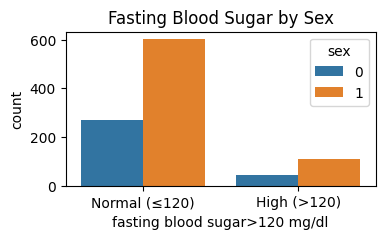

In [18]:
#plotting graphs on the basis of sex- fasting blood sugar level

plt.figure(figsize=(4,2))

sns.countplot(
    data=data,
    x='fasting blood sugar>120 mg/dl',
    hue='sex'
)
plt.xticks([0, 1], ['Normal (≤120)', 'High (>120)'])
plt.title('Fasting Blood Sugar by Sex')
plt.show()



KEY INSIGHTS FROM THE ABOVE GRAPH (Fasting blood sugar by Sex)
Males dominate the dataset — there are far more male patients than female, so the counts are naturally higher for males in both categories
Most patients have normal fasting blood sugar (FBS ≤ 120) regardless of sex
A small proportion have high FBS (>120) in both sexes
The male-to-female ratio stays roughly similar in both FBS groups, suggesting fasting blood sugar level doesn't strongly differ by sex in this dataset

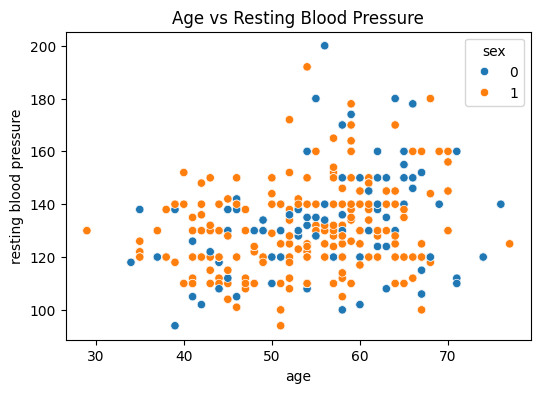

In [ ]:

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=data,
    x='age',
    y='resting blood pressure',
    hue='sex'
)

plt.title('Age vs Resting Blood Pressure')
plt.show()

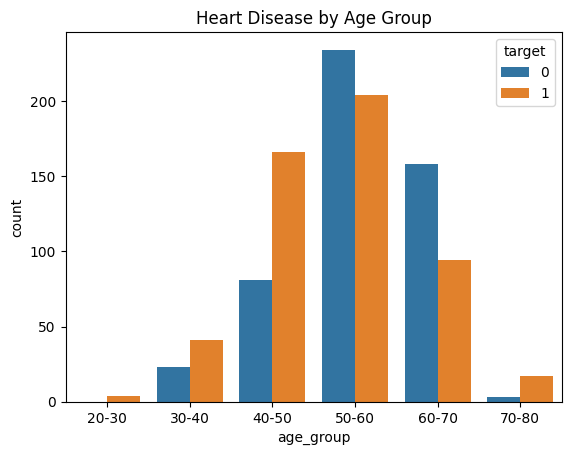

In [ ]:
data['age_group'] = pd.cut(
    data['age'],
    bins=[20,30,40,50,60,70,80],
    labels=['20-30','30-40','40-50','50-60','60-70','70-80']
)

sns.countplot(
    data=data,
    x='age_group',
    hue='target'
)

plt.title('Heart Disease by Age Group')
plt.show()

In [33]:
numeric_data = data.drop(columns=['age'])

correlation = numeric_data.corr()['target'].sort_values(ascending=False)

print(correlation)

target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


In [34]:
print(data['age'].unique())

[52 53 70 61 62 58 55 46 54 71 43 34 51 50 60 67 45 63 42 44 56 57 59 64
 65 41 66 38 49 48 29 37 47 68 76 40 39 77 69 35 74]


In [35]:
age_map = {
    '20-30': 25,
    '30-40': 35,
    '40-50': 45,
    '50-60': 55,
    '60-70': 65,
    '70-80': 75
}

data['age_group_numeric'] = data['age'].map(age_map)

In [36]:
data.select_dtypes(include=['number']).shape

(1025, 15)

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation of all features with target
correlation = data.corr()['target'].sort_values(ascending=False)
print(correlation)

target               1.000000
cp                   0.434854
thalach              0.422895
slope                0.345512
restecg              0.134468
fbs                 -0.041164
chol                -0.099966
trestbps            -0.138772
age                 -0.229324
sex                 -0.279501
thal                -0.337838
ca                  -0.382085
exang               -0.438029
oldpeak             -0.438441
age_group_numeric         NaN
Name: target, dtype: float64


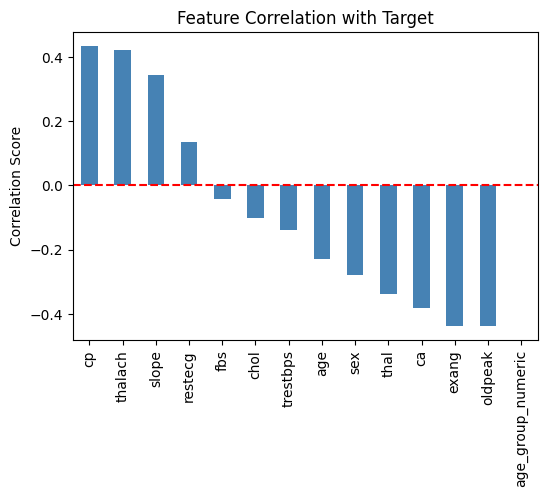

In [41]:
plt.figure(figsize=(6,4))
correlation.drop('target').plot(kind='bar', color='steelblue')
plt.title('Feature Correlation with Target')
plt.axhline(y=0, color='red', linestyle='--')
plt.ylabel('Correlation Score')
plt.show()

In [42]:
print(data['target'].value_counts())

target
1    526
0    499
Name: count, dtype: int64


In [43]:
print(data['target'].value_counts())
print(data['exang'].value_counts())

# Most important — see the actual relationship
print(data.groupby('exang')['target'].mean())

target
1    526
0    499
Name: count, dtype: int64
exang
0    680
1    345
Name: count, dtype: int64
exang
0    0.669118
1    0.205797
Name: target, dtype: float64


In [44]:
# Check exang vs target
print("exang vs target:")
print(data.groupby('exang')['target'].mean())
print()

# Check ca vs target  
print("ca (vessels) vs target:")
print(data.groupby('ca')['target'].mean())
print()

# Check oldpeak vs target
print("oldpeak vs target:")
print(data.groupby('target')['oldpeak'].mean())

exang vs target:
exang
0    0.669118
1    0.205797
Name: target, dtype: float64

ca (vessels) vs target:
ca
0    0.717993
1    0.292035
2    0.156716
3    0.130435
4    0.833333
Name: target, dtype: float64

oldpeak vs target:
target
0    1.600200
1    0.569962
Name: oldpeak, dtype: float64


In [45]:
# Flip the target
data['target'] = 1 - data['target']

# Verify after flipping
print(data['target'].value_counts())
print()
print(data.groupby('exang')['target'].mean())
print()
print(data.groupby('target')['oldpeak'].mean())

target
0    526
1    499
Name: count, dtype: int64

exang
0    0.330882
1    0.794203
Name: target, dtype: float64

target
0    0.569962
1    1.600200
Name: oldpeak, dtype: float64


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation of all features with target
correlation = data.corr()['target'].sort_values(ascending=False)
print(correlation)

target               1.000000
oldpeak              0.438441
exang                0.438029
ca                   0.382085
thal                 0.337838
sex                  0.279501
age                  0.229324
trestbps             0.138772
chol                 0.099966
fbs                  0.041164
restecg             -0.134468
slope               -0.345512
thalach             -0.422895
cp                  -0.434854
age_group_numeric         NaN
Name: target, dtype: float64


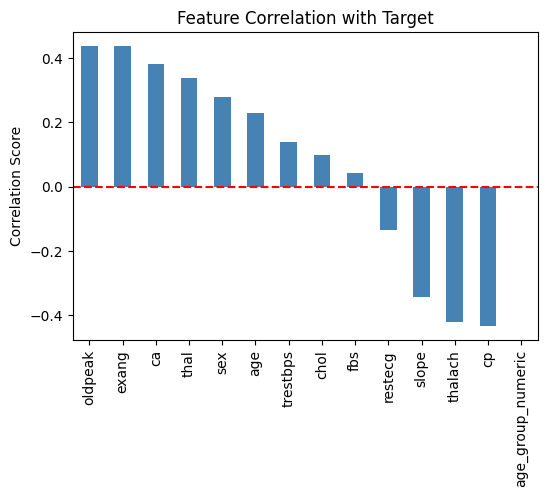

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation of all features with target
correlation = data.corr()['target'].sort_values(ascending=False)
print(correlation)

plt.figure(figsize=(6,4))
correlation.drop('target').plot(kind='bar', color='steelblue')
plt.title('Feature Correlation with Target')
plt.axhline(y=0, color='red', linestyle='--')
plt.ylabel('Correlation Score')
plt.show()